In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ==================================================
# Signal functions
# ==================================================

def spatial_grid(L, Nx):
    return np.linspace(-L / 2, L / 2, Nx, endpoint=False)


def gaussian_thickness_profile(x, d0, h, sigma, x0=0):
    return d0 + h * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))


def phase_signal(d, n, lam):
    k = 2 * np.pi / lam
    return n * k * d


def phi_from_f(f):
    alpha = np.sum(f)

    phi = np.sqrt(f / alpha)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    return phi, alpha


def plot_signal(x, f, n_qubits):
    plt.figure(figsize=(7, 4))

    plt.plot(x * 1e6, f)

    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title(f"Gaussian Phase Signal ({n_qubits} qubits)")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

n_qubits: 8
Nx: 256
alpha: 127.99675641225457
psi shape: (256,)
psi norm: 1.0
min psi: 0.0002409875815236627
max psi: 0.12483465781506499


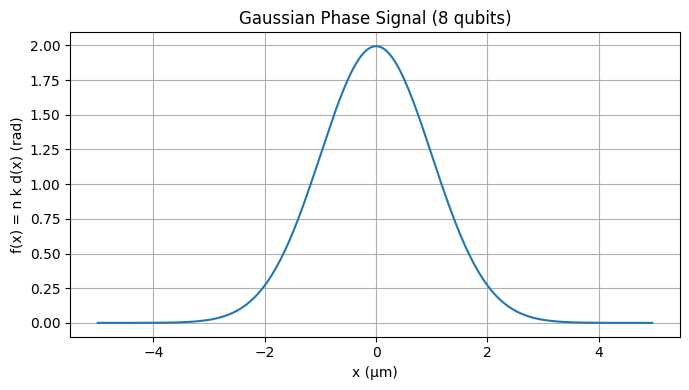

In [2]:
# ==================================================
# Parameters
# ==================================================

T = 10e-6

lam = 630e-9
n_refr = 1.0

d0 = 0.0
h = 200e-9
sigma = 1e-6
x0 = 0.0


# ==================================================
# Build psi for one chosen qubit number
# ==================================================

n_qubits = 8
Nx = 2 ** n_qubits

print("n_qubits:", n_qubits)
print("Nx:", Nx)

x = spatial_grid(T, Nx)

d = gaussian_thickness_profile(
    x=x,
    d0=d0,
    h=h,
    sigma=sigma,
    x0=x0
)

f = phase_signal(
    d=d,
    n=n_refr,
    lam=lam
)

psi, alpha = phi_from_f(f)

print("alpha:", alpha)
print("psi shape:", psi.shape)
print("psi norm:", np.linalg.norm(psi))
print("min psi:", np.min(np.abs(psi)))
print("max psi:", np.max(np.abs(psi)))

plot_signal(x, f, n_qubits)

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from qiskit.quantum_info import Statevector

# Bond dimension functions:
# exact + effective


def bond_dimensions_at_cut(
    state,
    n_qubits,
    cut,
    exact_tol=1e-2,
    weight_threshold=0.999
):
    

    state = np.asarray(state, dtype=complex)

    matrix = state.reshape(
        2 ** cut,
        2 ** (n_qubits - cut)
    )

    singular_values = np.linalg.svd(matrix, compute_uv=False)

    # -----------------------------
    # Exact bond dimension
    # -----------------------------
    exact_rank = np.sum(singular_values > exact_tol)

    # -----------------------------
    # Effective bond dimension
    # -----------------------------
    weights = singular_values ** 2

    if np.sum(weights) > 0:
        weights = weights / np.sum(weights)

    cumulative_weight = np.cumsum(weights)

    effective_rank = np.searchsorted(
        cumulative_weight,
        weight_threshold
    ) + 1

    return {
        "exact_rank": exact_rank,
        "effective_rank": effective_rank,
        "singular_values": singular_values,
        "weights": weights,
        "cumulative_weight": cumulative_weight,
    }


def max_bond_dimensions(
    state,
    n_qubits,
    exact_tol=1e-2,
    weight_threshold=0.999
):
    """
    Compute max exact and max effective bond dimension
    over all cuts.
    """

    exact_ranks = []
    effective_ranks = []
    all_singular_values = []
    all_weights = []
    all_cumulative_weights = []

    for cut in range(1, n_qubits):

        result = bond_dimensions_at_cut(
            state=state,
            n_qubits=n_qubits,
            cut=cut,
            exact_tol=exact_tol,
            weight_threshold=weight_threshold
        )

        exact_ranks.append(result["exact_rank"])
        effective_ranks.append(result["effective_rank"])
        all_singular_values.append(result["singular_values"])
        all_weights.append(result["weights"])
        all_cumulative_weights.append(result["cumulative_weight"])

    max_exact_D = max(exact_ranks)
    max_effective_D = max(effective_ranks)

    return {
        "max_exact_D": max_exact_D,
        "exact_rank_profile": exact_ranks,
        "max_effective_D": max_effective_D,
        "effective_rank_profile": effective_ranks,
        "singular_values_all_cuts": all_singular_values,
        "weights_all_cuts": all_weights,
        "cumulative_weights_all_cuts": all_cumulative_weights,
    }

In [ ]:
from qiskit_mps_initializer.datatypes import QuantumState


# Prepare psi


psi = np.asarray(psi, dtype=complex)
psi = psi / np.linalg.norm(psi)

n_qubits = int(np.log2(len(psi)))

target_state = Statevector(psi)

print("n_qubits:", n_qubits)
print("len(psi):", len(psi))
print("norm psi:", np.linalg.norm(psi))



# Scan over MPS initializer layers


layer_list = range(1, 101)

exact_tol = 1e-2
weight_threshold = 0.999

max_exact_results = []
max_effective_results = []

exact_rank_profile_results = []
effective_rank_profile_results = []

circuit_depth_results = []
circuit_size_results = []

for number_of_layers in layer_list:

    print("\n" + "=" * 70)
    print("number_of_layers =", number_of_layers)
    print("=" * 70)

    
    #MPS initializer circuit for this layer number
    
    psi_state = QuantumState.from_dense_data(data=psi,normalize=True)

    U_psi = psi_state.generate_mps_initializer_circuit(number_of_layers=number_of_layers)

    
    # dagger
    
    U_psi_dagger = U_psi.inverse()

    
    # Apply U dagger to target state
    
    
    chi_state = target_state.evolve(U_psi_dagger)

    chi = chi_state.data

    
    # Measure exact
    
    bond_result = max_bond_dimensions(
        state=chi,
        n_qubits=n_qubits,
        exact_tol=exact_tol,
        weight_threshold=weight_threshold
    )

    max_exact_D = bond_result["max_exact_D"]
    exact_profile = bond_result["exact_rank_profile"]

    max_effective_D = bond_result["max_effective_D"]
    effective_profile = bond_result["effective_rank_profile"]

    
    # results
    
    max_exact_results.append(max_exact_D)
    max_effective_results.append(max_effective_D)

    exact_rank_profile_results.append(exact_profile)
    effective_rank_profile_results.append(effective_profile)

    circuit_depth_results.append(U_psi.depth())
    circuit_size_results.append(U_psi.size())

    
    # Print
    
    print("Exact max bond dimension:", max_exact_D)
    print("Exact rank profile:", exact_profile)

    print("Effective max bond dimension:", max_effective_D)
    print("Effective rank profile:", effective_profile)

    print("Circuit depth:", U_psi.depth())
    print("Circuit size:", U_psi.size())

n_qubits: 8
len(psi): 256
norm psi: 1.0

number_of_layers = 1
Exact max bond dimension: 3
Exact rank profile: [np.int64(1), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(1), np.int64(1)]
Effective max bond dimension: 2
Effective rank profile: [np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1)]
Circuit depth: 10
Circuit size: 16

number_of_layers = 2
Exact max bond dimension: 3
Exact rank profile: [np.int64(1), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(1), np.int64(2)]
Effective max bond dimension: 1
Effective rank profile: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
Circuit depth: 12
Circuit size: 24

number_of_layers = 3
Exact max bond dimension: 2
Exact rank profile: [np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1)]
Effective max bond dimension: 1
Effective rank profile: [np.int64(1), np.int64(1), np.int64(1), np.int64(1),

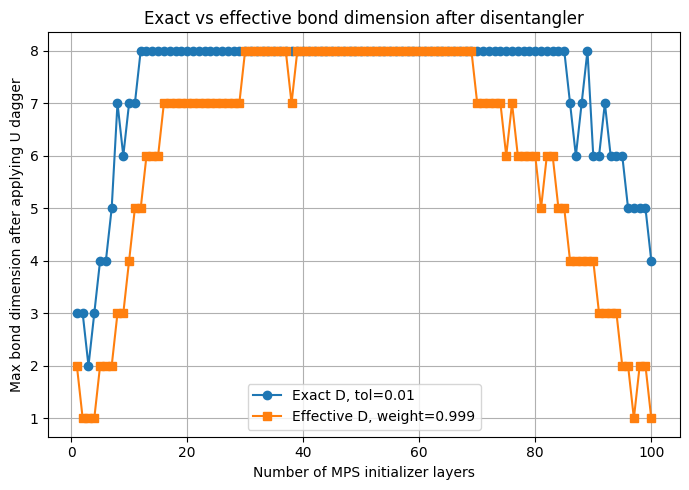

In [5]:
plt.figure(figsize=(7, 5))

plt.plot(
    list(layer_list),
    max_exact_results,
    marker="o",
    label=f"Exact D, tol={exact_tol}"
)

plt.plot(
    list(layer_list),
    max_effective_results,
    marker="s",
    label=f"Effective D, weight={weight_threshold}"
)

plt.xlabel("Number of MPS initializer layers")
plt.ylabel("Max bond dimension after applying U dagger")
plt.title("Exact vs effective bond dimension after disentangler")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()